# 3. XGBoost — Predicting Smartphone Addiction

Primer modelo de árboles del episodio. Frente al baseline lineal de `2_logit.ipynb`
(**CV AUC = 0,91687**), XGBoost tiene dos ventajas estructurales sobre este dataset:

- **No hay que imputar.** Los NaN se manejan de forma nativa: el algoritmo aprende una dirección de
  *default* por cada split. El EDA encontró entre 4 % y 19 % de nulos en **todas** las features, y el
  logit pagó por rellenarlos — `daily_screen_time_hours` rendía AUC 0,890 medida sólo donde está
  presente, contra 0,865 en CV al imputar con la mediana.
- **No hay que inventar un encoding.** `gender`, `stress_level` y `academic_work_impact` son
  nominales; con `enable_categorical=True` se pasan como dtype `category` y no se les impone el orden
  falso que introduciría un `OrdinalEncoder`.

**Validación:** `StratifiedKFold(5)` con *early stopping* por fold, predicciones out-of-fold reales y
predicción de test promediada entre los 5 modelos.

> **Tiempo de ejecución: ~15-20 minutos.** Corre en CPU (`tree_method="hist"`): este equipo no tiene
> GPU NVIDIA. Como referencia medida: ~96 s por cada 1000 árboles por fold.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED    = 42
N_FOLDS = 5

## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "addicted_label"

crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]


def agregar_derivadas(df):
    """Identica a la de 2_logit.ipynb, para que ambos modelos sean comparables."""
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET].values

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Tasa base P(y=1): {y.mean():.4f}")

Train: 691,369 filas x 21 columnas
Test:  296,302 filas x 20 columnas
Tasa base P(y=1): 0.7094


In [3]:
# Dtype categorico con vocabulario compartido entre train y test, para que los codigos internos
# coincidan en ambos splits (mismo patron que 3_logit_xgb_ensemble.ipynb del Episodio 3).
for col in crudas_cat:
    niveles = sorted(set(train[col].dropna()) | set(test[col].dropna()))
    dtype   = pd.CategoricalDtype(categories=niveles, ordered=False)
    train[col] = train[col].astype(dtype)
    test[col]  = test[col].astype(dtype)
    print(f"  {col:22s} -> {niveles}")

print("\nNulos que quedan sin imputar (XGBoost los maneja nativamente):")
print(train[crudas_num + derivadas + crudas_cat].isnull().sum().to_string())

  gender                 -> ['Female', 'Male', 'Other']
  stress_level           -> ['High', 'Low', 'Medium']
  academic_work_impact   -> ['No', 'Yes']

Nulos que quedan sin imputar (XGBoost los maneja nativamente):
age                         28929
daily_screen_time_hours     95854
weekend_screen_time        112063
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
otro_uso                    95854
ocio_horas                 207088
screen_sleep               132019
social_ratio               189109
gaming_ratio               183646
weekend_ratio              173463
min_per_open               161550
gender                      29034
stress_level                55148
academic_work_impact        44224


## 2. Configuración del Modelo

Parámetros conservadores, sin búsqueda de hiperparámetros: el techo de 3000 árboles es alto a
propósito y quien decide cuántos se usan realmente es el **early stopping** contra el fold de
validación. Así cada fold corta donde le conviene y no hace falta fijar `n_estimators` a mano.

In [4]:
PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=3000,          # techo; el early stopping corta mucho antes
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",         # CPU: este equipo no tiene GPU NVIDIA
    enable_categorical=True,
    early_stopping_rounds=100,
    random_state=SEED,
    n_jobs=-1,
)


def cv_xgboost(X, y, X_test, params, skf, etiqueta=""):
    """5-fold CV con early stopping. Devuelve OOF real y test promediado entre folds."""
    oof      = np.zeros(len(X), dtype=np.float32)
    test_sum = np.zeros(len(X_test), dtype=np.float32)
    aucs, iters, modelos = [], [], []

    print(f"{'='*62}")
    print(f"CROSS-VALIDATION — {etiqueta}")
    print(f"{'='*62}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        modelo = XGBClassifier(**params)
        modelo.fit(X.iloc[tr_idx], y[tr_idx],
                   eval_set=[(X.iloc[val_idx], y[val_idx])], verbose=False)

        p_val         = modelo.predict_proba(X.iloc[val_idx])[:, 1]
        oof[val_idx]  = p_val
        test_sum     += modelo.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y[val_idx], p_val)
        aucs.append(auc)
        iters.append(modelo.best_iteration)
        modelos.append(modelo)
        print(f"  Fold {fold}: AUC = {auc:.5f}  |  best_iteration = {modelo.best_iteration}")

    print(f"{'='*62}")
    print(f"  Media: {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")
    print(f"  AUC out-of-fold: {roc_auc_score(y, oof):.5f}")
    print(f"  Arboles usados (media): {np.mean(iters):.0f}")
    print(f"{'='*62}\n")

    return dict(oof=oof, test=test_sum / skf.get_n_splits(),
                aucs=aucs, iters=iters, modelos=modelos)

## 3. Validación Cross-Validation

Se comparan los mismos dos conjuntos de features que en el logit. Ahí las derivadas sumaban +0,0054
porque un modelo lineal no puede construir cocientes por su cuenta; un modelo de árboles sí puede
aproximar interacciones, así que la pregunta abierta es si le siguen aportando algo.

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

configs = {
    "B. crudas":             crudas_num + crudas_cat,
    "C. crudas + derivadas": crudas_num + derivadas + crudas_cat,
}

resultados = {}
for nombre, feats in configs.items():
    resultados[nombre] = cv_xgboost(train[feats], y, test[feats], PARAMS, skf, etiqueta=nombre)
    resultados[nombre]["features"] = feats

MEJOR    = max(resultados, key=lambda k: np.mean(resultados[k]["aucs"]))
res      = resultados[MEJOR]
features = res["features"]
cv_mean  = np.mean(res["aucs"])

print(f"{'='*62}")
print("COMPARATIVA DE CONFIGURACIONES")
print(f"{'='*62}")
for nombre, r in resultados.items():
    print(f"  {nombre:24s} AUC = {np.mean(r['aucs']):.5f} +/- {np.std(r['aucs']):.5f}")
print(f"{'='*62}")
print(f"  Mejor: {MEJOR}  (AUC = {cv_mean:.5f})")

CROSS-VALIDATION — B. crudas
  Fold 1: AUC = 0.96373  |  best_iteration = 2432
  Fold 2: AUC = 0.96438  |  best_iteration = 2468
  Fold 3: AUC = 0.96452  |  best_iteration = 2756
  Fold 4: AUC = 0.96521  |  best_iteration = 2497
  Fold 5: AUC = 0.96407  |  best_iteration = 2699
  Media: 0.96438 +/- 0.00050
  AUC out-of-fold: 0.96438
  Arboles usados (media): 2570

CROSS-VALIDATION — C. crudas + derivadas
  Fold 1: AUC = 0.96418  |  best_iteration = 2326
  Fold 2: AUC = 0.96481  |  best_iteration = 2382
  Fold 3: AUC = 0.96474  |  best_iteration = 1802
  Fold 4: AUC = 0.96575  |  best_iteration = 2412
  Fold 5: AUC = 0.96441  |  best_iteration = 2154
  Media: 0.96478 +/- 0.00054
  AUC out-of-fold: 0.96478
  Arboles usados (media): 2215

COMPARATIVA DE CONFIGURACIONES
  B. crudas                AUC = 0.96438 +/- 0.00050
  C. crudas + derivadas    AUC = 0.96478 +/- 0.00054
  Mejor: C. crudas + derivadas  (AUC = 0.96478)


## 4. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold (C. crudas + derivadas): 0.96478


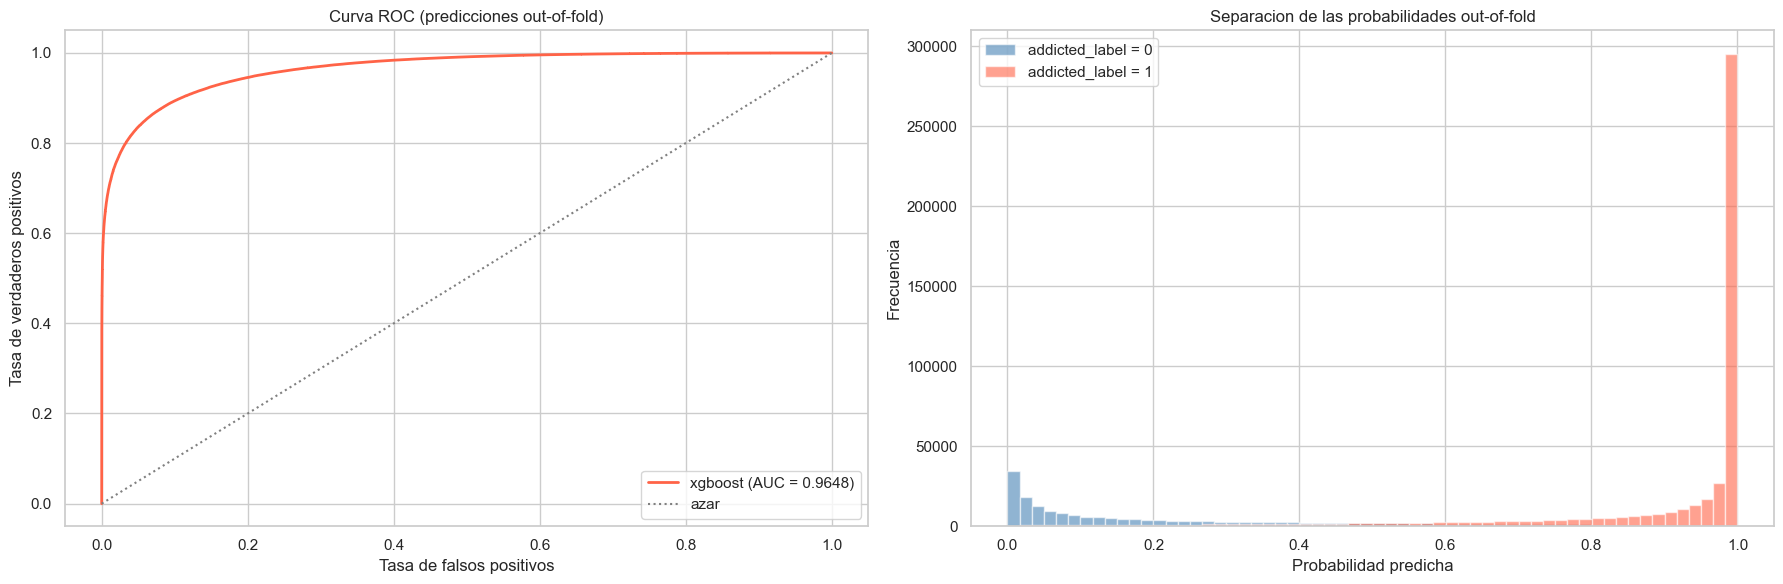

In [6]:
oof     = res["oof"]
auc_oof = roc_auc_score(y, oof)
print(f"AUC out-of-fold ({MEJOR}): {auc_oof:.5f}")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"xgboost (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color in [(0, "steelblue"), (1, "tomato")]:
    axes[1].hist(oof[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"addicted_label = {cls}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance

Con early stopping cada fold corta en un `best_iteration` distinto, así que no hay un único "modelo
final": la importancia se promedia entre los 5 modelos y se muestra el desvío como barra de error.

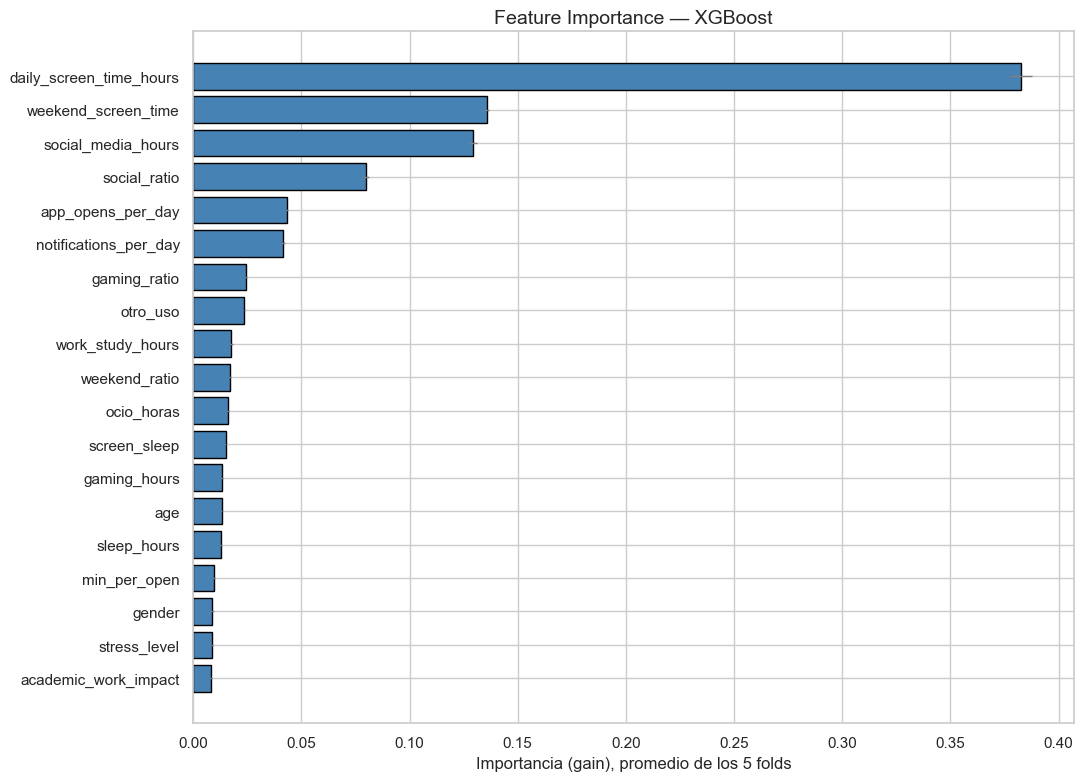

Ordenada por importancia:
daily_screen_time_hours    0.3825
weekend_screen_time        0.1356
social_media_hours         0.1292
social_ratio               0.0798
app_opens_per_day          0.0433
notifications_per_day      0.0414
gaming_ratio               0.0244
otro_uso                   0.0237
work_study_hours           0.0177
weekend_ratio              0.0171
ocio_horas                 0.0159
screen_sleep               0.0150
gaming_hours               0.0132
age                        0.0131
sleep_hours                0.0128
min_per_open               0.0097
gender                     0.0089
stress_level               0.0087
academic_work_impact       0.0082


In [7]:
imps      = pd.DataFrame([m.feature_importances_ for m in res["modelos"]], columns=features)
imp_media = imps.mean().sort_values()
imp_std   = imps.std().reindex(imp_media.index)

fig, ax = plt.subplots(figsize=(11, max(6, len(features) * 0.42)))
ax.barh(imp_media.index, imp_media.values, xerr=imp_std.values,
        color="steelblue", edgecolor="black", error_kw=dict(ecolor="gray", lw=1))
ax.set_xlabel("Importancia (gain), promedio de los 5 folds")
ax.set_title("Feature Importance — XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

print("Ordenada por importancia:")
print(imp_media.sort_values(ascending=False).round(4).to_string())

## 6. Comparación con el Baseline Lineal

In [8]:
AUC_LOGIT = 0.91687   # CV AUC de 2_logit.ipynb (crudas + derivadas)

comparativa = pd.DataFrame({
    "modelo":  ["Logit (2_logit.ipynb)", f"XGBoost ({MEJOR})"],
    "CV AUC":  [AUC_LOGIT, cv_mean],
})
comparativa["delta vs logit"] = (comparativa["CV AUC"] - AUC_LOGIT).round(5)

print(f"{'='*62}")
print("COMPARATIVA DE MODELOS")
print(f"{'='*62}")
print(comparativa.round(5).to_string(index=False))
print(f"{'='*62}")

COMPARATIVA DE MODELOS
                         modelo  CV AUC  delta vs logit
          Logit (2_logit.ipynb) 0.91687         0.00000
XGBoost (C. crudas + derivadas) 0.96478         0.04791


## 7. Predicción sobre Test y Submission

In [9]:
proba_test = res["test"]

submission = pd.DataFrame({"id": test["id"], TARGET: proba_test})
submission.to_csv("../submissions/3_xgboost_submission.csv", index=False)

# OOF y predicciones de test para un ensamble futuro (models/ esta gitignoreado)
np.save("../models/3_xgboost_oof.npy",  res["oof"])
np.save("../models/3_xgboost_test.npy", proba_test)

print(f"Submission escrita: ../submissions/3_xgboost_submission.csv ({len(submission):,} filas)")
print(submission.head().to_string(index=False))
print(f"\nProbabilidad media predicha: {proba_test.mean():.4f}"
      f"  (tasa base en train: {y.mean():.4f})")

Submission escrita: ../submissions/3_xgboost_submission.csv (296,302 filas)
    id  addicted_label
691369        0.999597
691370        0.924110
691371        0.938780
691372        0.990862
691373        0.999066

Probabilidad media predicha: 0.7097  (tasa base en train: 0.7094)


In [10]:
# Chequeo de sanidad contra sample_submission (formato e ids)
sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "los ids no estan alineados"
assert submission[TARGET].between(0, 1).all(), "hay probabilidades fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos en la prediccion"
print("Chequeos OK — submission lista para enviar.")

Chequeos OK — submission lista para enviar.


## 8. Envío a Kaggle vía API

Las dos celdas siguientes están marcadas para **no ejecutarse**. En este equipo la CLI de Kaggle
falla con `CERTIFICATE_VERIFY_FAILED` contra `api.kaggle.com`; el workaround del bundle de
certificados está en `Episode 6 - Predicting Stellar Class/notebook/3_catboost.ipynb`.

In [11]:
COMPETITION = "playground-series-s6e8"
FILE        = "../submissions/3_xgboost_submission.csv"
MSG         = f"XGBoost - cat nativas + NaN nativos - CV AUC={cv_mean:.5f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Smartphone Addiction



  0%|          | 0.00/5.26M [00:00<?, ?B/s]
  0%|          | 16.0k/5.26M [00:00<01:00, 91.1kB/s]
 11%|█         | 576k/5.26M [00:00<00:03, 1.41MB/s] 
 13%|█▎        | 704k/5.26M [00:00<00:06, 742kB/s] 
 85%|████████▌ | 4.47M/5.26M [00:01<00:00, 7.09MB/s]
100%|██████████| 5.26M/5.26M [00:02<00:00, 2.72MB/s]


In [12]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e8

     ref  fileName                  date                        description                                           status                     publicScore  privateScore  
--------  ------------------------  --------------------------  ----------------------------------------------------  -------------------------  -----------  ------------  
55419015  3_xgboost_submission.csv  2026-08-11 00:30:06.843000  XGBoost - cat nativas + NaN nativos - CV AUC=0.96478  SubmissionStatus.PENDING                              
55393493  2_logit_submission.csv    2026-08-10 01:23:28.337000  Logit - crudas + derivadas - CV AUC=0.91687           SubmissionStatus.COMPLETE  0.91909                    


## 9. Conclusiones

- **CV AUC = 0,96478** con `crudas + derivadas` (±0,00054 entre folds). El AUC out-of-fold da
  exactamente lo mismo (0,96478), así que la estimación es sólida.
- **+0,0479 sobre el baseline lineal** (0,91687 → 0,96478). Es un salto grande para un cambio de
  familia de modelo **sin ningún tuning**, y confirma lo que ya sospechaba `2_logit.ipynb`: el dataset
  tiene interacciones y cortes no lineales que una frontera lineal no puede representar.
- **Las derivadas casi no aportan acá**: +0,0004 (0,96438 → 0,96478), contra los +0,0054 que valían en
  el logit. Los árboles reconstruyen esas relaciones por su cuenta. Lo que sí cambian es la
  **velocidad de convergencia**: con derivadas el early stopping corta en 2215 árboles promedio contra
  2570 sin ellas. Y `social_ratio` queda 4ª en importancia (0,0798), así que no son inertes — son
  redundantes.
- **El early stopping cortó por sí solo en todos los folds**: los `best_iteration` van de 1802 a 2756
  y, sumándoles las 100 rondas de paciencia, el fold más largo entrenó ~2856 árboles — ninguno llegó a
  tocar el techo de 3000. O sea que el modelo dejó de mejorar por su cuenta y **subir el cap no
  aportaría nada**; la palanca que queda es el tuning de hiperparámetros, no más árboles.
- **Dos variables que el análisis lineal había descartado por ruido resultan útiles**:
  `app_opens_per_day` (importancia 0,0433, 5º puesto) y `notifications_per_day` (0,0414, 6º) tenían
  correlación 0,064 y −0,012 con el target. Los árboles les encuentran señal vía interacciones — es el
  caso de manual de por qué la correlación lineal no sirve como criterio de selección de features para
  un modelo no lineal.
- **El tope del ranking se mantiene estable** entre EDA, logit y XGBoost: `daily_screen_time_hours`
  (0,3825), `weekend_screen_time` (0,1356) y `social_media_hours` (0,1292) concentran el 65 % de la
  importancia.
- **Las categóricas confirman ser inertes**: `gender`, `stress_level` y `academic_work_impact` son las
  tres últimas del ranking (~0,008 cada una), consistente con las tasas planas que mostró el EDA.
- **Sin señales de shift**: probabilidad media sobre test 0,7097 contra una tasa base de 0,7094.
- **Score público en Kaggle: 0,96634**, contra el CV de 0,96478 (+0,0016). El leaderboard vuelve a dar
  por encima de la validación cruzada, igual que con el logit (+0,0022): la CV es un proxy confiable y
  consistentemente conservador.
- **Próximos pasos**: tuning de hiperparámetros, que es lo único que este modelo no tiene. Las
  predicciones out-of-fold quedan guardadas en `../models/3_xgboost_oof.npy` para ensamblar.

> Seguimiento en `4_lightgbm.ipynb`: LightGBM llega a **CV AUC 0,96422** (empate técnico, −0,00056) y
> su correlación de rangos con este modelo es de **0,9955**, así que el ensamble de los dos sólo suma
> +0,00016 en OOF — por debajo del desvío entre folds. En el leaderboard el blend sacó **0,96634**,
> exactamente el mismo score que este XGBoost solo: la ganancia era ruido. Este sigue siendo el modelo
> individual más fuerte del episodio.